# Synthetic dataset
### In this exercise, you will apply some of the steps you have already applied in Exercise 1 on a different dataset. **This will highlight some of the weaknesses of decision trees.**

#### Synthetic 2d dataset
This is a very simple 2d dataset that will help you understand some of the limitations of decision trees. It contains 2 synthetic features, each ranging from 0 to 10, and a target class (0 or 1).

- You can download it from the following link as a CSV file:
https://raw.githubusercontent.com/dbdmg/data-science-lab/master/datasets/2d-synthetic.csv

- Load the synthetic dataset you have previously downloaded.
- This dataset has two features and a class label.

> Use matplotlib’s scatter() function to plot the dataset on a 2D plane and color the points based on their class label.

#### matplotlib.pyplot.scatter(x, y, s=None, c=None, *, marker=None, cmap=None, norm=None, vmin=None, vmax=None, alpha=None, linewidths=None, edgecolors=None, colorizer=None, plotnonfinite=False, data=None, **kwargs)

- How do you expect a decision tree to approach data distributed in this way?

In [ ]:
import pandas as pd
import numpy as np

from IPython.display import display

import matplotlib.pyplot as plt

import graphviz

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import export_graphviz

In [ ]:
DF = pd.read_csv('../..Dataset/LAB4/2d-synthetic.csv', sep=',')
print(DF)

# I don't know how to use matplotlib --> very concerning!!
# DF.plot(kind='scatter', x='x0', y='x1', c='label')
plt.scatter(
    DF['x0'],
    DF['x1'],
    c=DF['label'])      # matplotlib is smart enough so that if you pass the labels as colour it will colour each point according to their label
    # cmap='bwr')

plt.show()

We can see that the points are distributed following a very precise geometry: they're divided half and half, not mixing with each other

#### Let's see how will the decision tree perform with this kind of data:
# 2. Build a “default” decision tree using the entire dataset, then visualize the learned model. What is the tree learning, and why?

In [ ]:
# 0. 'fix' the loaded data so that it can be split into train and test
# 1. split data into training and test data --> split_train_test
# 2. create the standard decision tree
# 3. fit it
# 4. predict
# 5. evaluate with accuracy

y = DF['label']
y = y.to_numpy()

x0 = DF['x0'].to_numpy()
x1 = DF['x1'].to_numpy()
x = np.column_stack((x0, x1))

otherwise = False
if otherwise:
    x = DF.values[:, :2]    # --> From the DataFrame, take all rows (:) and the first two columns (:2)
    y = DF.values[:, 2]     # --> From the DataFrame, take all rows (:), but only column 2

# print(x)

# THIS EXACT ORDER, ALWASY
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
clf = DecisionTreeClassifier()
clf.fit(x_train, y_train)
predictions = clf.predict(x_test)
train_pred = clf.predict(x_train)
train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test, predictions)

print("Train accuracy:", train_acc)
print("Test  accuracy:", test_acc)

# # let's visualize the tree
# dot_data = export_graphviz(clf, out_file=None, 
#                            feature_names = np.array(['x0','x1']),
#                            class_names= np.array(['0','1']),
#                            filled=True, rounded=True,  
#                            special_characters=True)

# # Use Graphviz to visualize the tree
# graph = graphviz.Source(dot_data)
# graph.render("decision_tree_2", format="png")  # Saves the visualization as a PNG file
# graph.view()  # Opens the image using the default viewer



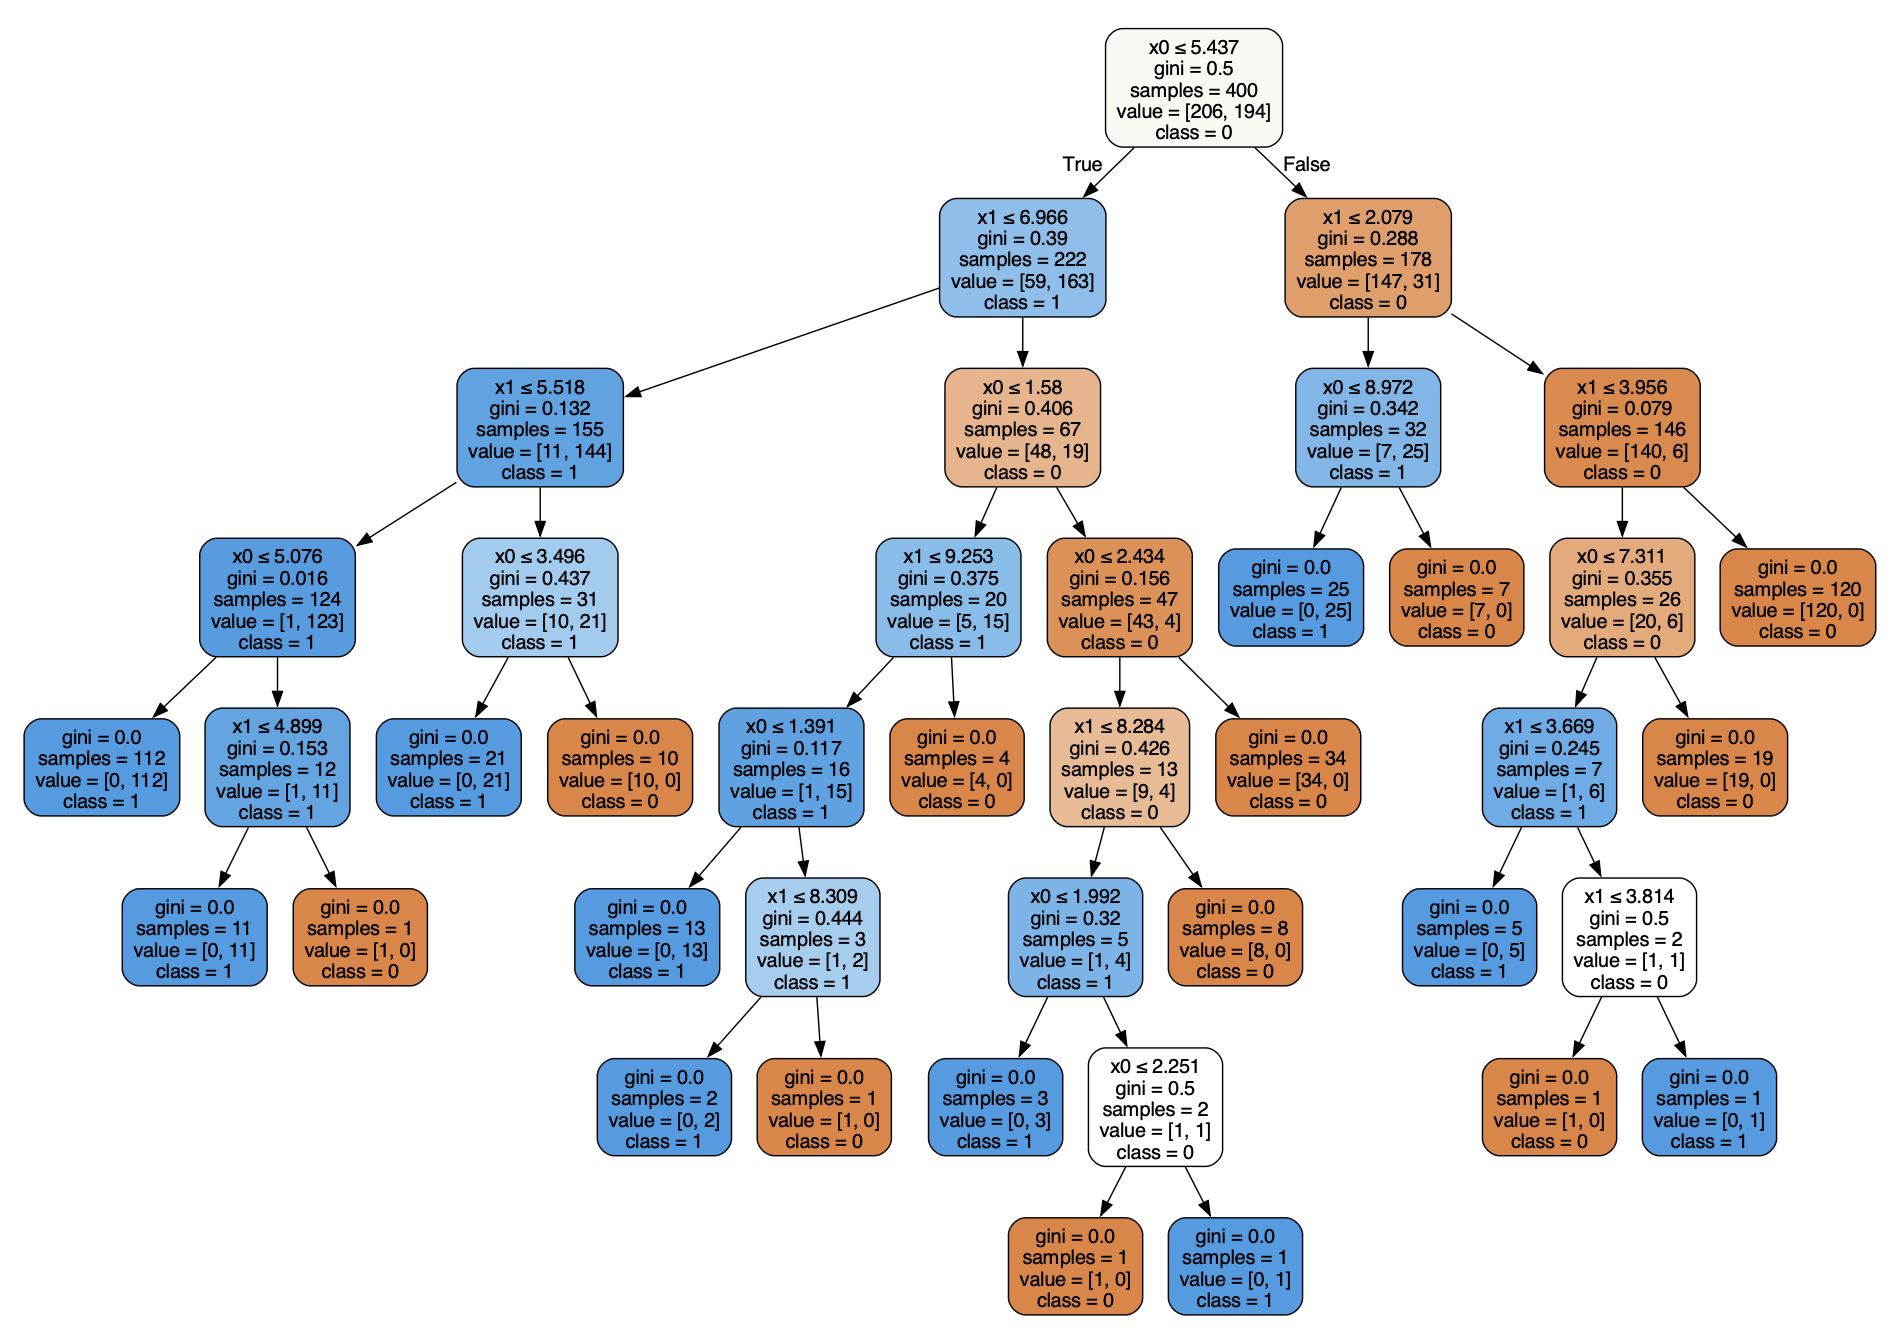

# Not so sure .... maybe it's overfitting :)
The tree:
- is extremely deep
- has tons of leaves with 1 or 2 samples
- keeps splitting even when the region is almost uniform
- produces a jagged, overly-specific decision boundary

> This is classic structural / complexity overfitting.

#### Even if performance is good, the model is far more complex than needed.
#### BUT it' important to specify that we couldn't say it's overfitting by comparing training and test accuracy


# As expected, the decision tree is not capable of separating this linearly separable problem with a "simple" solution. We can say that the tree is not "learning" the underlying rationale behind the data. Instead, it tries to approximate the data as best it can with what it can do.